## Loading Data

In [339]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

gen_mean_std = np.load('/Users/isaaclee/Wildfire_Research/recursive_wildfire_results/depth_4_epochs_10000_schedule_VE_sigma_2/generated_mean_std.npz')
gen_samples = np.load('/Users/isaaclee/Wildfire_Research/recursive_wildfire_results/depth_4_epochs_10000_schedule_VE_sigma_2/generated_samples.npz')
real_samples = np.load('/Users/isaaclee/Wildfire_Research/recursive_wildfire_results/depth_4_epochs_10000_schedule_VE_sigma_2/real_samples.npz')
training_data = np.load('/Users/isaaclee/Wildfire_Research/recursive_data/recursive_train_data_norm.npy')
testing_data = np.load('/Users/isaaclee/Wildfire_Research/recursive_data/recursive_test_data_norm.npy')

pred_means = gen_mean_std['array1']
pred_stds = gen_mean_std['array2']
dist_samples = gen_samples['arr_0']
real_samples = real_samples['arr_0']

print(pred_means.shape)
print(pred_stds.shape)
print(dist_samples.shape)
print(real_samples.shape)

print(training_data.shape)
print(testing_data.shape)

(1200, 3)
(1200, 3)
(1200000, 3)
(1200, 3)
(14000, 27)
(1200, 27)


## Undoing Normalization

In [340]:
from scipy.stats import norm

x1_min = np.load('/Users/isaaclee/Wildfire_Research/recursive_data/recursive_x1_min.npy')
x2_min = np.load('/Users/isaaclee/Wildfire_Research/recursive_data/recursive_x2_min.npy')
x3_min = np.load('/Users/isaaclee/Wildfire_Research/recursive_data/recursive_x3_min.npy')

x1_max = np.load('/Users/isaaclee/Wildfire_Research/recursive_data/recursive_x1_max.npy')
x2_max = np.load('/Users/isaaclee/Wildfire_Research/recursive_data/recursive_x2_max.npy')
x3_max = np.load('/Users/isaaclee/Wildfire_Research/recursive_data/recursive_x3_max.npy')

x1_first_max = np.load('/Users/isaaclee/Wildfire_Research/recursive_data/first_x1_max.npy')
x2_first_max = np.load('/Users/isaaclee/Wildfire_Research/recursive_data/first_x2_max.npy')
x3_first_max = np.load('/Users/isaaclee/Wildfire_Research/recursive_data/first_x3_max.npy')

x1_pred = pred_means[:,0]
x2_pred = pred_means[:,1]
x3_pred = pred_means[:,2]

x1_new = x1_pred * (x1_max - x1_min) + x1_min
x2_new = x2_pred * (x2_max - x2_min) + x2_min
x3_new = x3_pred * (x3_max - x3_min) + x3_min

x1 = norm.cdf(x1_new) * x1_first_max
x2 = norm.cdf(x2_new) * x2_first_max
x3 = norm.cdf(x3_new) * x3_first_max

pred_means[:,0] = x1
pred_means[:,1] = x2
pred_means[:,2] = x3

# Unnormalizing real values

real_x1 = real_samples[:,0]
real_x2 = real_samples[:,1]
real_x3 = real_samples[:,2]

real_x1_new = real_x1 * (x1_max - x1_min) + x1_min
real_x2_new = real_x2 * (x2_max - x2_min) + x2_min
real_x3_new = real_x3 * (x3_max - x3_min) + x3_min

real_x1_orig = norm.cdf(real_x1_new) * x1_first_max
real_x2_orig = norm.cdf(real_x2_new) * x2_first_max
real_x3_orig = norm.cdf(real_x3_new) * x3_first_max

real_samples[:,0] = real_x1_orig
real_samples[:,1] = real_x2_orig
real_samples[:,2] = real_x3_orig

## Undoing normalization for pred distributions and calculating std

In [341]:
print(dist_samples.shape)

dist_x1 = dist_samples[:,0]
dist_x2 = dist_samples[:,1]
dist_x3 = dist_samples[:,2]

dist_x1_new = dist_x1 * (x1_max - x1_min) + x1_min
dist_x2_new = dist_x2 * (x2_max - x2_min) + x2_min
dist_x3_new = dist_x3 * (x3_max - x3_min) + x3_min

dist_x1_orig = norm.cdf(dist_x1_new) * x1_first_max
dist_x2_orig = norm.cdf(dist_x2_new) * x2_first_max
dist_x3_orig = norm.cdf(dist_x3_new) * x3_first_max

dist_samples[:,0] = dist_x1_orig
dist_samples[:,1] = dist_x2_orig
dist_samples[:,2] = dist_x3_orig

dist_x1_orig = dist_x1_orig.reshape(1200,1000)
dist_x2_orig = dist_x2_orig.reshape(1200,1000)
dist_x3_orig = dist_x3_orig.reshape(1200,1000)

print(dist_x1_orig.shape)
print(dist_x2_orig.shape)
print(dist_x3_orig.shape)

std_x1 = np.std(dist_x1_orig, axis=1)
std_x2 = np.std(dist_x2_orig, axis=1)
std_x3 = np.std(dist_x3_orig, axis=1)

print(std_x1.shape)
print(std_x2.shape)
print(std_x3.shape)

(1200000, 3)
(1200, 1000)
(1200, 1000)
(1200, 1000)
(1200,)
(1200,)
(1200,)


## x1 analysis

In [342]:
real = real_samples[:,0]
pred = pred_means[:,0]

print(real.shape)
print(pred.shape)

mape = np.mean(np.abs(real-pred)/real)
print("Mean Absolute Percent Error: " + str(mape))

(1200,)
(1200,)
Mean Absolute Percent Error: 0.6231659407715104


In [343]:
within_1_std = np.abs(real-pred) <= std_x1
proportions = within_1_std.astype(int)
print(np.mean(proportions))

0.4033333333333333


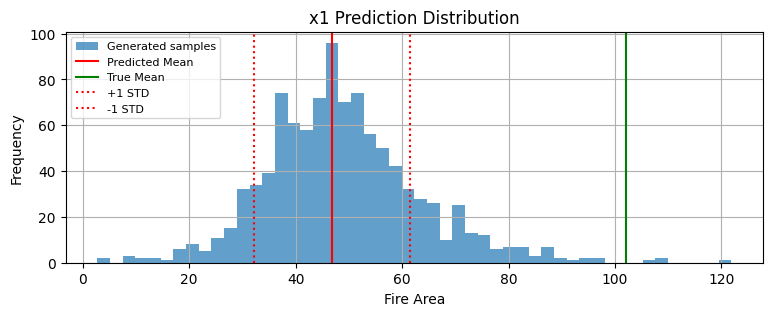

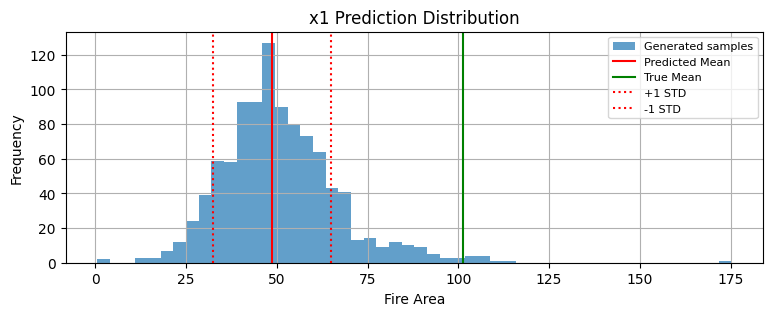

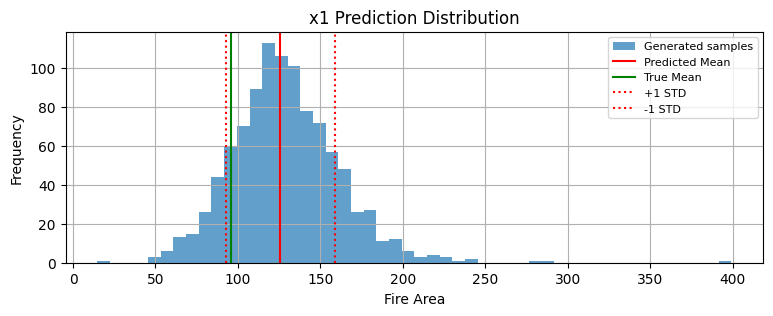

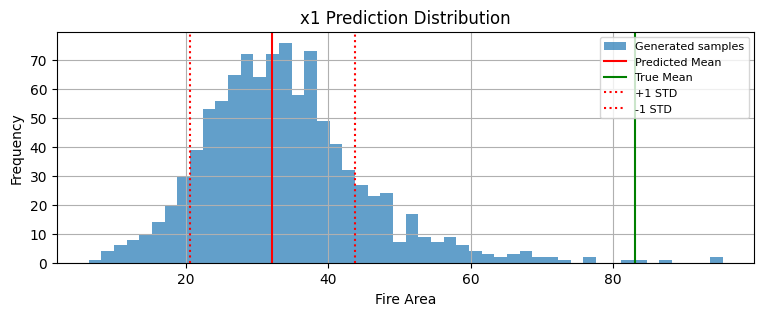

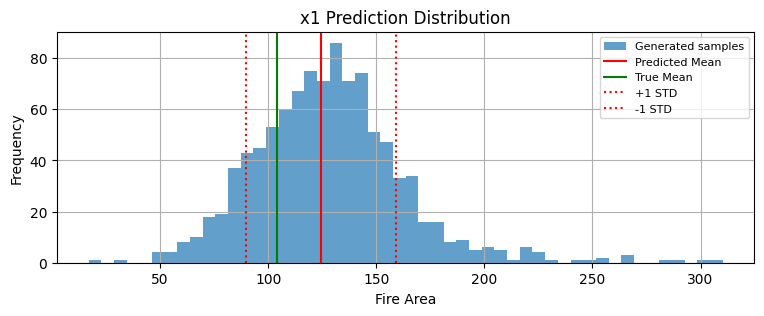

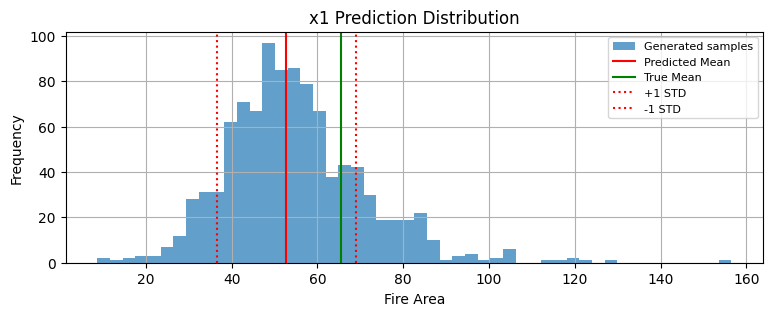

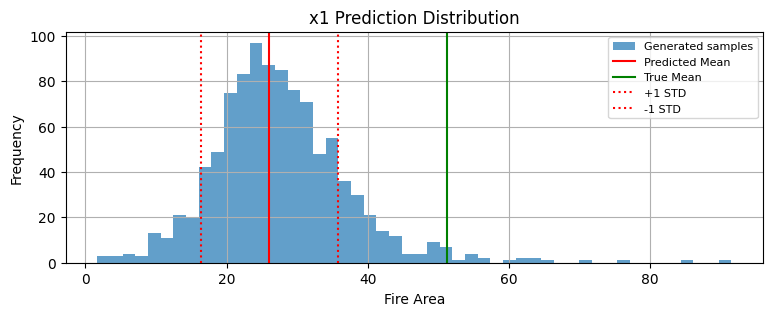

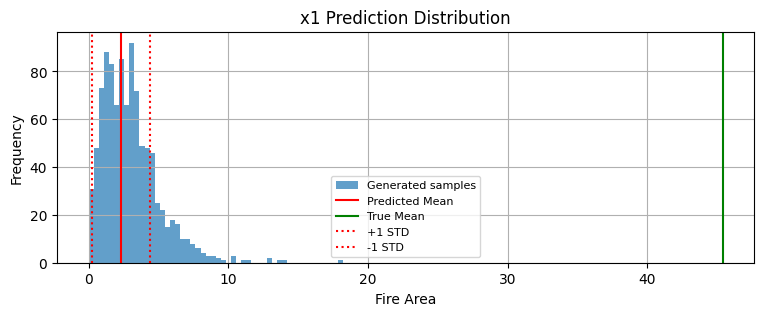

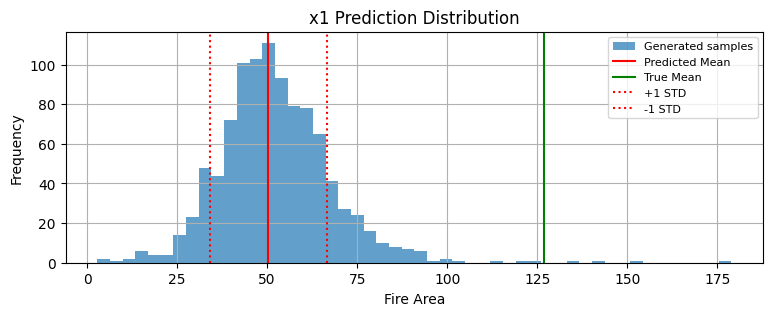

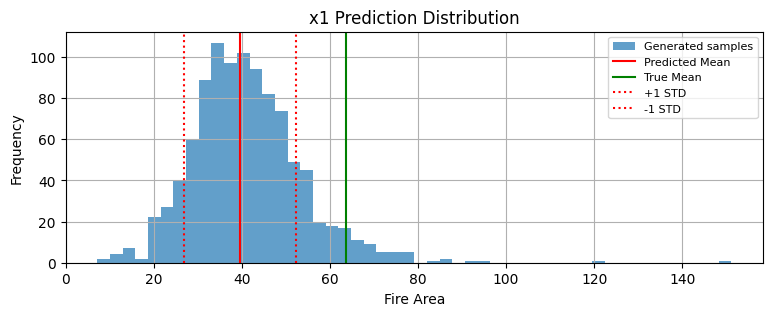

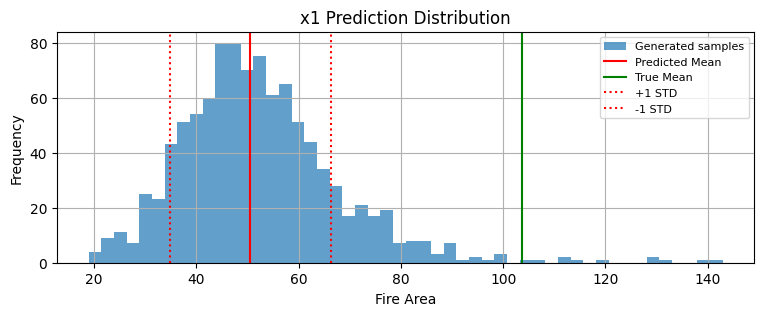

In [344]:
for i in range (3, 14):
    plt.figure(figsize=(9,3))
    plt.title('x1 Prediction Distribution')
    plt.hist(dist_x1_orig[i], bins=50, alpha=0.7, label='Generated samples') 
    plt.xlabel('Fire Area')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.axvline(pred[i], color='red', label='Predicted Mean')
    plt.axvline(real[i], color='green', label='True Mean')
    plt.axvline(pred[i]+std_x1[i], color='red', label='+1 STD', linestyle=':')
    plt.axvline(pred[i]-std_x1[i], color='red', label='-1 STD', linestyle=':')
    plt.legend(fontsize='8')
    plt.show()

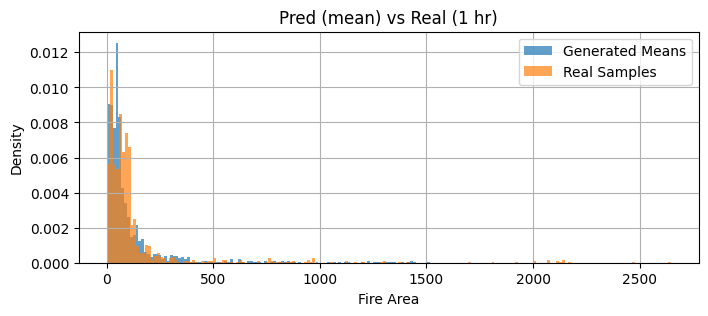

In [345]:
plt.figure(figsize=(8,3))
plt.title('Pred (mean) vs Real (1 hr)')
plt.hist(pred, bins='auto', alpha=0.7, label='Generated Means', density=True)
plt.hist(real, bins='auto', alpha=0.7, label='Real Samples', density=True)
plt.legend()
plt.xlabel('Fire Area')
plt.ylabel('Density')
plt.grid(True)
plt.show()

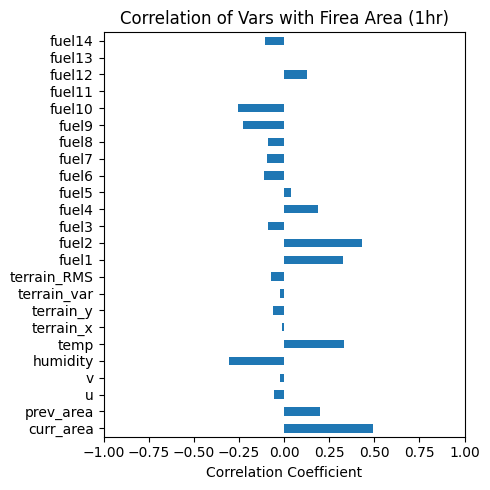

In [346]:
pred_data = testing_data
pred_data[:,0] = pred

pred_data = np.delete(pred_data, [1,2], axis=1)

col_names = ["x1_area", "curr_area", "prev_area", "u", "v", "humidity", "temp", "terrain_x", "terrain_y", "terrain_var", "terrain_RMS", "fuel1", "fuel2", "fuel3", "fuel4", "fuel5", "fuel6", "fuel7", "fuel8", "fuel9", "fuel10", "fuel11", "fuel12","fuel13", "fuel14"]
pred_df = pd.DataFrame(pred_data, columns=col_names)
pred_corr = pred_df.corr().iloc[0, 1:]

plt.figure(figsize=(5, 5))
pred_corr.plot(kind='barh')
plt.xlim(-1, 1)
plt.title("Correlation of Vars with Firea Area (1hr)")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

## x2 analysis

In [347]:
real = real_samples[:,1]
pred = pred_means[:,1]

mape = np.mean(np.abs(real-pred)/real)
print("Mean Absolute Percent Error: " + str(mape))

Mean Absolute Percent Error: 0.6377965455735773


In [348]:
within_1_std = np.abs(real-pred) <= std_x2
proportions = within_1_std.astype(int)
print(np.mean(proportions))

0.34833333333333333


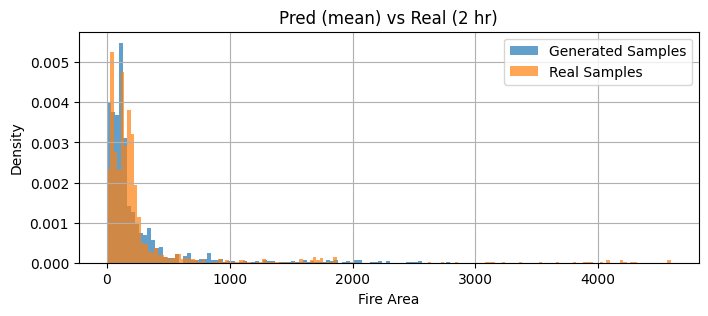

In [349]:
plt.figure(figsize=(8,3))
plt.title('Pred (mean) vs Real (2 hr)')
plt.hist(pred, bins='auto', alpha=0.7, label='Generated Samples', density=True)
plt.hist(real, bins='auto', alpha=0.7, label='Real Samples', density=True)
plt.legend()
plt.xlabel('Fire Area')
plt.ylabel('Density')
plt.grid(True)
plt.show()

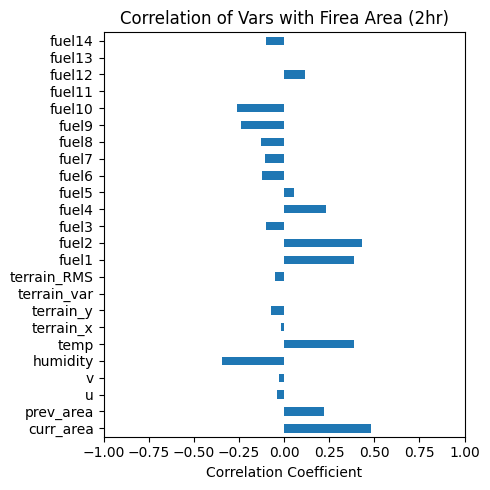

In [350]:
pred_data = testing_data
pred_data[:,1] = pred

pred_data = np.delete(pred_data, [0,2], axis=1)

col_names = ["x2_area", "curr_area", "prev_area", "u", "v", "humidity", "temp", "terrain_x", "terrain_y", "terrain_var", "terrain_RMS", "fuel1", "fuel2", "fuel3", "fuel4", "fuel5", "fuel6", "fuel7", "fuel8", "fuel9", "fuel10", "fuel11", "fuel12","fuel13", "fuel14"]
pred_df = pd.DataFrame(pred_data, columns=col_names)
pred_corr = pred_df.corr().iloc[0, 1:]

plt.figure(figsize=(5, 5))
pred_corr.plot(kind='barh')
plt.xlim(-1, 1)
plt.title("Correlation of Vars with Firea Area (2hr)")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

## x3 analysis

In [351]:
real = real_samples[:,2]
pred = pred_means[:,2]

mape = np.mean(np.abs(real-pred)/real)
print("Mean Absolute Percent Error: " + str(mape))

Mean Absolute Percent Error: 0.6216146882202122


In [352]:
within_1_std = np.abs(real-pred) <= std_x3
proportions = within_1_std.astype(int)
print(np.mean(proportions))

0.3233333333333333


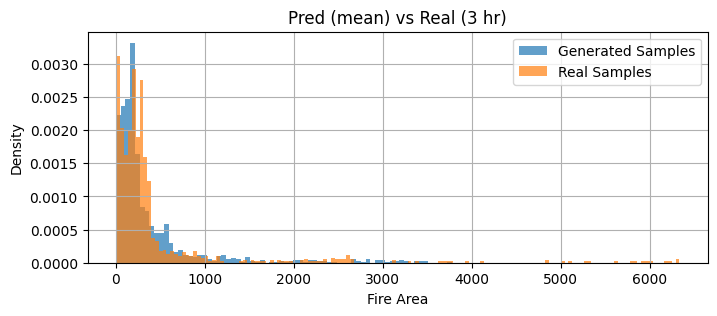

In [353]:
plt.figure(figsize=(8,3))
plt.title('Pred (mean) vs Real (3 hr)')
plt.hist(pred, bins='auto', alpha=0.7, label='Generated Samples', density=True)
plt.hist(real, bins='auto', alpha=0.7, label='Real Samples', density=True)
plt.legend()
plt.xlabel('Fire Area')
plt.ylabel('Density')
plt.grid(True)
plt.show()

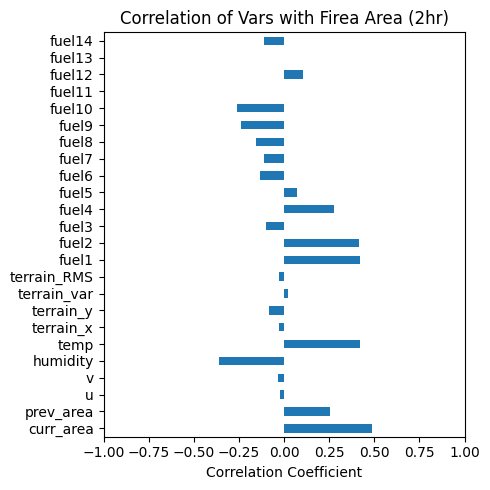

In [354]:
pred_data = testing_data
pred_data[:,2] = pred

pred_data = np.delete(pred_data, [0,1], axis=1)

col_names = ["x2_area", "curr_area", "prev_area", "u", "v", "humidity", "temp", "terrain_x", "terrain_y", "terrain_var", "terrain_RMS", "fuel1", "fuel2", "fuel3", "fuel4", "fuel5", "fuel6", "fuel7", "fuel8", "fuel9", "fuel10", "fuel11", "fuel12","fuel13", "fuel14"]
pred_df = pd.DataFrame(pred_data, columns=col_names)
pred_corr = pred_df.corr().iloc[0, 1:]

plt.figure(figsize=(5, 5))
pred_corr.plot(kind='barh')
plt.xlim(-1, 1)
plt.title("Correlation of Vars with Firea Area (2hr)")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

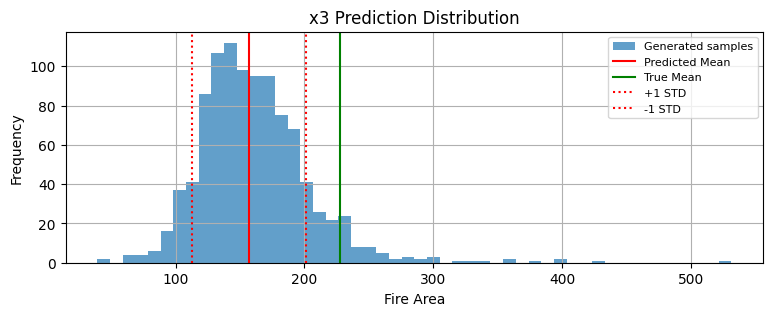

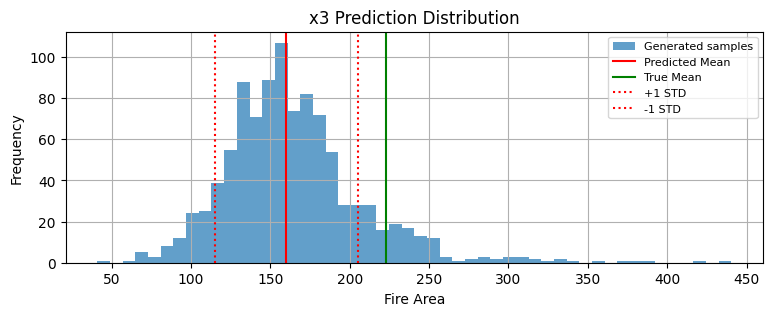

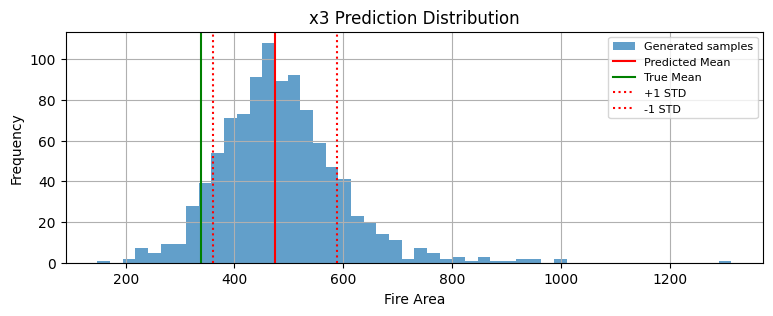

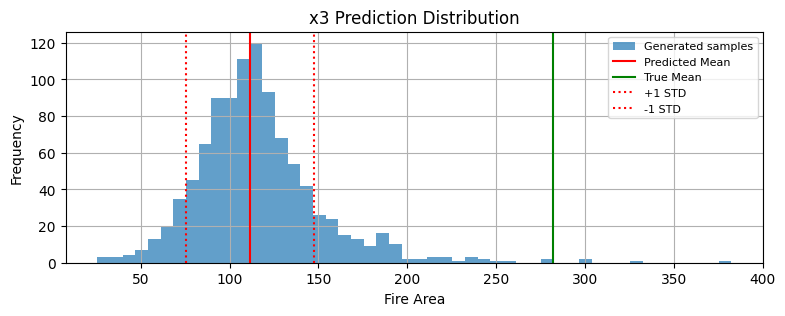

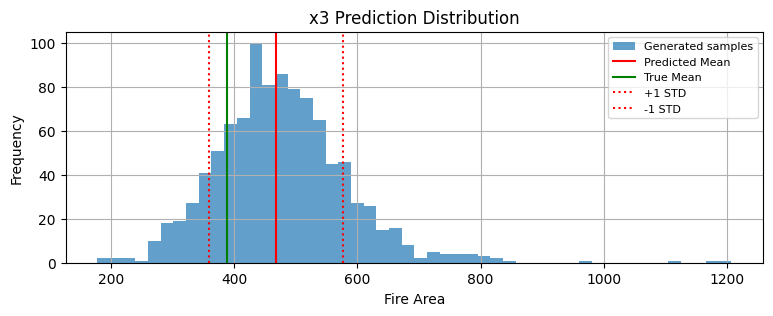

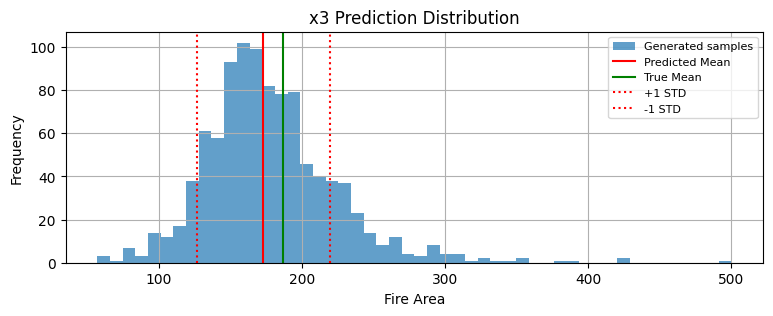

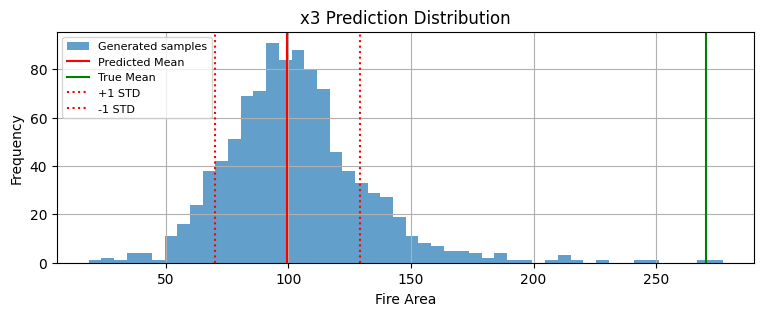

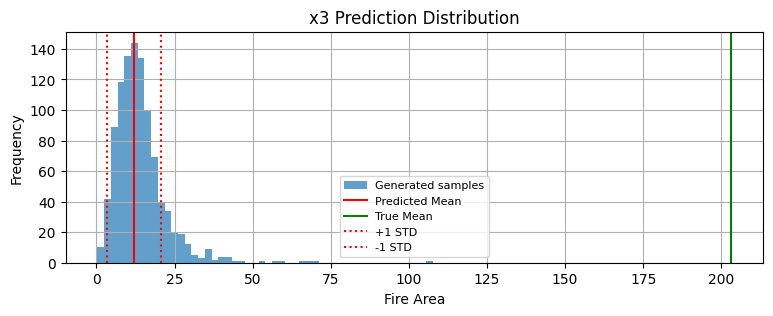

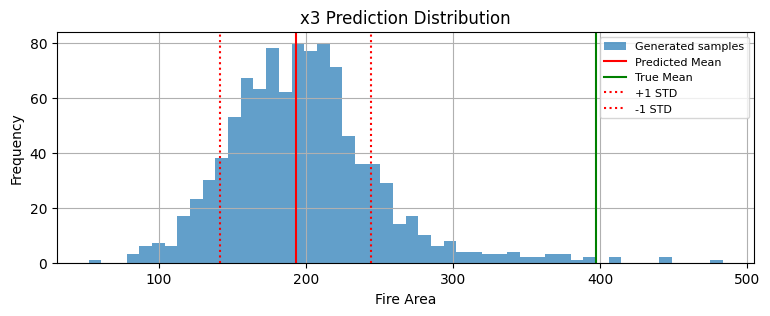

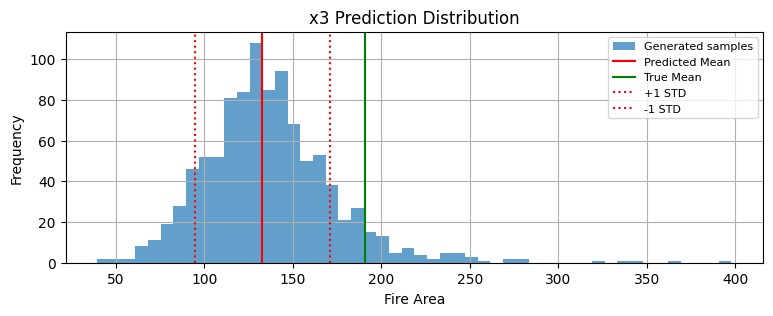

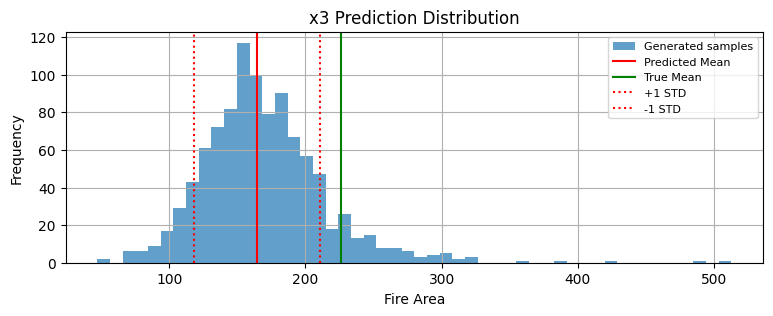

In [355]:
for i in range (3, 14):
    plt.figure(figsize=(9,3))
    plt.title('x3 Prediction Distribution')
    plt.hist(dist_x3_orig[i], bins=50, alpha=0.7, label='Generated samples') 
    plt.xlabel('Fire Area')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.axvline(pred[i], color='red', label='Predicted Mean')
    plt.axvline(real[i], color='green', label='True Mean')
    plt.axvline(pred[i]+std_x3[i], color='red', label='+1 STD', linestyle=':')
    plt.axvline(pred[i]-std_x3[i], color='red', label='-1 STD', linestyle=':')
    plt.legend(fontsize='8')
    plt.show()